# Setup

In [67]:
from stat_test_tools import *

descriptions = {
    "max_fit": "Fitness (max fitness)",
    "div": "Behavioral diversity"
}

container_naming = {
    "add_novelty": "inc. fitness",
    "sub_novelty": "inc. novelty",
    "novelty": "pure novelty",
    "novelty_archiving": "novetly archive",
    "novelty_limit": "limit archive",
    "fit_archiving": "fit. archive",
    "elite_archiving": "elite archive",
    "fitness":"fitness"
}

env_naming = {
    "lunarlander": "Lunar Lander",
    "cartpole": "Cartpole"
}

alg_naming = {
    "lambda": "ES",
    "diff": "DE"
}

hyperparameter_naming = {
    "m": "$\lambda$",
    "l": "$\mu$",
    "mutation_sigma": "$\sigma$",
    "archive_batch": "arch. batch",
    "archiving_period": "arch. T",
    "cross_method": "method",
    "fitness_weight":"$W_0$",
    "decay":"$r_D$",
    "cross_uni": "$p_U$"
}

datasets = {"cartpole":"server_try0", "lunarlander":"server_try3"}

def table_to_latex(dk):
    dk = dk.replace(["NaN", "nan", None], np.nan)
    new_columns = [hyperparameter_naming[col] if col in hyperparameter_naming else col for col in dk.columns]
    dk.columns = new_columns
    index = [container_naming[col] if col in container_naming else col for col in dk.index]
    dk.index = index
    dk=dk.fillna("-")
    if "method" in dk.columns:
        dk["method"] = dk["method"].apply(lambda x: "A" if x =="mean" else "U")
    latex = dk.to_latex(
        index=True,
        escape=False,
        formatters= [fmt] * len(dk.columns),
        column_format="l" + "c" * len(dk.columns)
    )
    return latex
def fmt(x):
    if pd.isna(x):
        return "-"
    if isinstance(x, (int, float)):
        if x == 0:
            return "0"
        elif abs(x) < 1e-3:
            mantissa, exp = f"{x:.3e}".split("e")
            return rf"$\mathbf{{{mantissa} \times 10^{{{int(exp)}}}}}$"
        else:
            if x < 0.05:
                return rf"$\textbf{{{x:.3f}}}$"
            return f"{x:.3f}"
    if x in container_naming:
        return container_naming[x]
    return str(x)


def fmt_no_highlight(x):
    if pd.isna(x):
        return "-"
    if isinstance(x, (int, float)):
        if x == 0:
            return "0"
        elif abs(x) < 1e-3:
            mantissa, exp = f"{x:.2e}".split("e")
            return rf"${{mantissa}}\times 10^{{{int(exp)}}}$"
        else:
            return f"{x:.2f}"
    if x in container_naming:
        return container_naming[x]
    return str(x)

# Grid protocols

In [2]:
ens = ["lunarlander", "cartpole"]
grid_datasets = {"cartpole":"server_try0", "lunarlander":"server_try2"}
for en in ens:
    for alg in ["lambda", "diff"]:
        df = get_protocol_table(en, alg, grid_datasets[en])
        df.to_csv(f"./Data/grid_protocol/{en}_{alg}.csv")
dk = df["origin"].copy()
dk


Found 1 files!
Found 1 files!
Found 1 files!
Found 1 files!
Found 1 files!
Found 1 files!
Found 1 files!
Found 1 files!
[{'crossmethod': 'uniform', 'lambda': 70, 'mu': 50, 'mutation_rate': 0.02, 'cross_rate': 0.5, 'sigma': 2.5, 'archiving_period': 5, 'archive_batch': 4, 'limit': -90.0, 'cross': 0.5}]
{'cross_method': 'uniform', 'l': 55, 'm': 50, 'mr': 0.02, 'cr': 0.6, 'mutation_sigma': 2.5, 'archiving_period': 5, 'archive_batch': 4, 'limit': -90.0, 'cross_uni': 0.5}
Found 1 files!
Found 1 files!
Found 1 files!
Found 1 files!
Found 1 files!
Found 1 files!
Found 1 files!
Found 1 files!
[{'lambda': 50, 'mutation_rate': 0.8, 'cross_rate': 0.8, 'archiving_period': 2, 'archive_batch': 1, 'limit': -180.0}]
{'l': 60, 'mr': 0.9, 'cr': 0.8, 'archiving_period': 2, 'archive_batch': 1, 'limit': -180.0}
Found 1 files!
Found 1 files!
Found 1 files!
Found 1 files!
Found 1 files!
Found 1 files!
Found 1 files!
Found 1 files!
[{'crossmethod': 'uniform', 'lambda': 20, 'mu': 30, 'mutation_rate': 0.06, 'cro

,archive_batch,archiving_period,cr,decay,fitness_weight,l,limit,mr
fitness,NaN,NaN,1.0,NaN,NaN,15.0,NaN,0.5
novelty,NaN,NaN,1.0,NaN,NaN,20.0,NaN,0.8
add_novelty,NaN,NaN,0.9,2.5,1.0,10.0,NaN,1.0
sub_novelty,NaN,NaN,1.0,3.5,0.4,10.0,NaN,0.7
fit_archiving,3.0,3.0,0.9,NaN,NaN,20.0,NaN,0.9
elite_archiving,4.0,2.0,0.5,NaN,NaN,20.0,NaN,0.8
novelty_archiving,3.0,3.0,0.8,NaN,NaN,15.0,NaN,0.6
novelty_limit,3.0,3.0,1.0,NaN,NaN,20.0,240.0,0.9


In [3]:
from tabulate import tabulate
en = "lunarlander"
alg = "lambda"
df2 = pd.read_csv(f"./Data/grid_protocol/{en}_{alg}.csv", header=[0,1], index_col=[0])
if alg =="lambda":
       df2=df2.drop([("final","cross_method"), ("origin", "cross_method")], axis=1)
delta =  df2["final"] - df2["origin"]
delta = delta.loc[~(delta.fillna(0) == 0).all(axis=1)]
mask = ~delta.fillna(0).eq(0).all(axis=0)
delta = delta.loc[:, mask]
delta= delta.replace({0:"-"})
latex = table_to_latex(delta)
print(latex)

\begin{tabular}{lcccc}
\toprule
{} &   cr &             $\mu$ &         $\lambda$ &    mr \\
\midrule
pure novelty    & -0.1 &                 - &                 - &     - \\
inc. fitness    &    - &             15.00 &                 - &     - \\
inc. novelty    &  0.1 &                 - &  $\textbf{x:.2f}$ &  0.05 \\
fit. archive    &    - &             30.00 &             15.00 &   0.1 \\
elite archive   & -0.1 &                 - &             15.00 &   0.1 \\
novetly archive & -0.1 &             15.00 &             15.00 &     - \\
limit archive   &  0.1 &  $\textbf{x:.2f}$ &                 - &     - \\
\bottomrule
\end{tabular}



/tmp/ipykernel_405997/1687786701.py:52: FutureWarning: In future versions `DataFrame.to_latex` is expected to utilise the base implementation of `Styler.to_latex` for formatting and rendering. The arguments signature may therefore change. It is recommended instead to use `DataFrame.style.to_latex` which also contains additional functionality.
  latex = dk.to_latex(


In [4]:

#delta = delta.loc[~(delta.fillna(0) == 0).all()]
# mask = ~delta.fillna(0).eq(0).all(axis=0)
# delta = delta.loc[:, mask]

# delta.to_csv(f"./Data/grid_protocol/delta_{en}_{alg}.csv")


latex = table_to_latex(dk)
print(latex)

\begin{tabular}{lcccccccc}
\toprule
{} & arch. batch & arch. T &   cr & $r_D$ & $W_0$ & $\mu$ &  limit &   mr \\
\midrule
fitness         &           - &       - & 1.00 &     - &     - & 15.00 &      - & 0.50 \\
pure novelty    &           - &       - & 1.00 &     - &     - & 20.00 &      - & 0.80 \\
inc. fitness    &           - &       - & 0.90 &   2.5 &   1.0 & 10.00 &      - & 1.00 \\
inc. novelty    &           - &       - & 1.00 &   3.5 &   0.4 & 10.00 &      - & 0.70 \\
fit. archive    &         3.0 &     3.0 & 0.90 &     - &     - & 20.00 &      - & 0.90 \\
elite archive   &         4.0 &     2.0 & 0.50 &     - &     - & 20.00 &      - & 0.80 \\
novetly archive &         3.0 &     3.0 & 0.80 &     - &     - & 15.00 &      - & 0.60 \\
limit archive   &         3.0 &     3.0 & 1.00 &     - &     - & 20.00 &  240.0 & 0.90 \\
\bottomrule
\end{tabular}



/tmp/ipykernel_405997/1687786701.py:52: FutureWarning: In future versions `DataFrame.to_latex` is expected to utilise the base implementation of `Styler.to_latex` for formatting and rendering. The arguments signature may therefore change. It is recommended instead to use `DataFrame.style.to_latex` which also contains additional functionality.
  latex = dk.to_latex(


# Gens graph

Found 1 files!
Found 1 files!
Found 1 files!
Found 1 files!
Found 1 files!
Found 1 files!
Found 1 files!
Found 1 files!
Found 1 files!
Found 1 files!
Found 1 files!
Found 1 files!
Found 1 files!
Found 1 files!
Found 1 files!
Found 1 files!
Found 1 files!
Found 1 files!
Found 1 files!
Found 1 files!
Found 1 files!
Found 1 files!
Found 1 files!
Found 1 files!
Found 1 files!
Found 1 files!
Found 1 files!
Found 1 files!
Found 1 files!
Found 1 files!
Found 1 files!
Found 1 files!


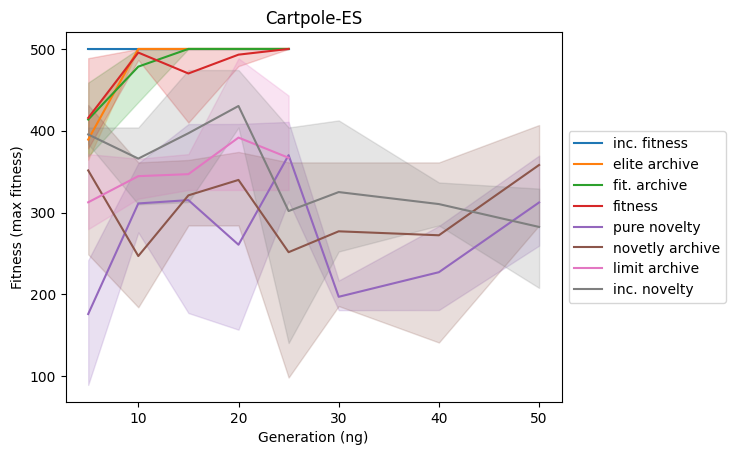

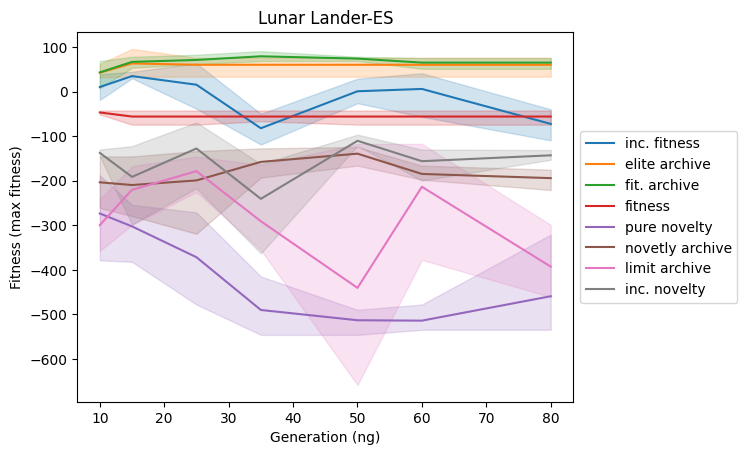

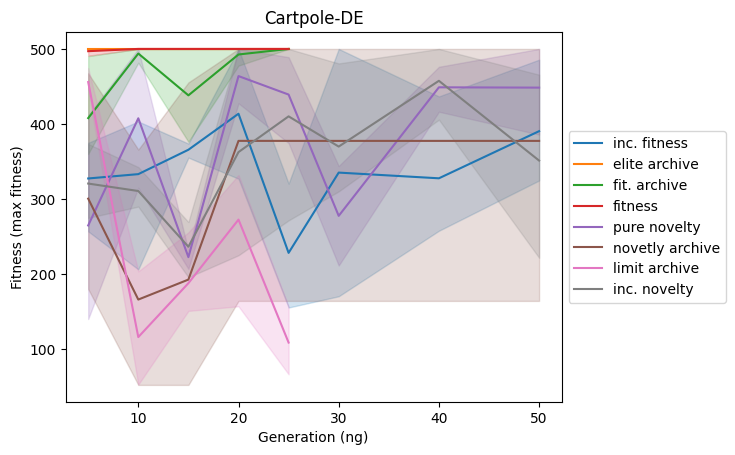

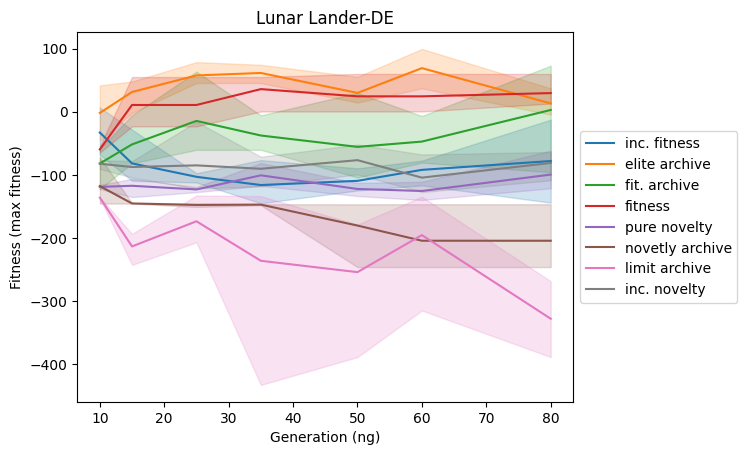

In [5]:
import constants as cst
import matplotlib.pyplot as plt
en = "lunarlander"
alg = "diff"
names = {"lunarlander":"server_try3", "cartpole":"server_try0"}

def create_figures(names, attr):
    path = "./Docs/vzor-dp/img/"
    for alg in ["lambda", "diff"]:
        for en in cst.ENIVROMENTS:
            plt.figure()
            ax = plot_generations(en=en, alg=alg, name=names[en], attr=attr)
            handles, labels = ax.get_legend_handles_labels()
            new_labels = [container_naming[l] for l in labels]
            ax.legend_.remove()
            ax.set_xlabel("Generation (ng)")
            ax.set_ylabel(descriptions[attr])
            plt.legend(handles, new_labels, loc="center left", bbox_to_anchor=(1, 0.5))
            plt.title(f"{env_naming[en]}-{alg_naming[alg]}")
            plt.savefig(path + f"generations_{en}_{alg}_{attr}.pdf", bbox_inches="tight")

create_figures(names, "max_fit")

In [6]:
print(df.columns.tolist())

[('final', 'archive_batch'), ('final', 'archiving_period'), ('final', 'cr'), ('final', 'decay'), ('final', 'fitness_weight'), ('final', 'l'), ('final', 'limit'), ('final', 'mr'), ('origin', 'archive_batch'), ('origin', 'archiving_period'), ('origin', 'cr'), ('origin', 'decay'), ('origin', 'fitness_weight'), ('origin', 'l'), ('origin', 'limit'), ('origin', 'mr')]


In [7]:
df = gen_extract_values(load_gen_direct_data("cartpole", "fitness", "lambda", "server_try0"))
df.groupby("ng").median()

Found 1 files!


/tmp/ipykernel_405997/2083778437.py:2: FutureWarning: The default value of numeric_only in DataFrameGroupBy.median is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  df.groupby("ng").median()


,max_fit,avg_fit,median_fit,min_fit,std_fit,div
ng,,,,,,
5,380.0,248.844444,182.166667,38.333333,137.925233,0.547401
10,500.0,320.355556,380.000000,23.666667,150.994717,0.391541
15,500.0,238.411111,181.500000,14.166667,152.964761,0.386958
20,500.0,215.944444,245.666667,9.833333,136.345529,0.549736
25,500.0,223.366667,224.000000,25.500000,144.079880,0.527765


# Statistical tests

## Algorithms

In [51]:
total = wilcoxon_test_total_algorithms(datasets, "fitnesses")
total

(89642.0, 0.03870676244646096)

In [52]:
ll_wilcoxon = wilcoxon_test_per_environment_algorithms("lunarlander",datasets, "fitnesses")
carpole_wilcoxon = wilcoxon_test_per_environment_algorithms("cartpole",datasets, "fitnesses")

-54.22316957560915
29.124999999999996


In [53]:
ll_wilcoxon

(18713.0, 3.113835150920772e-12, -54.22316957560915)

In [54]:
carpole_wilcoxon

(13428.0, 0.0002129582820475215, 29.124999999999996)

## Containers

### Friedman

In [68]:
f_c = friedman_test_per_environment_containers("cartpole", datasets, "fitnesses")
f_l =friedman_test_per_environment_containers("lunarlander", datasets, "fitnesses")
print(f_c)
print(f_l)

FriedmanchisquareResult(statistic=326.65791750793215, pvalue=1.2158324856403088e-66)
FriedmanchisquareResult(statistic=328.39150568933593, pvalue=5.177754695041798e-67)


In [69]:
f_c = friedman_test_per_environment_containers("cartpole", datasets, "behaviors")
f_l =friedman_test_per_environment_containers("lunarlander", datasets, "behaviors")
print(f_c)
print(f_l)

FriedmanchisquareResult(statistic=163.91859695565856, pvalue=4.7999219391876454e-32)
FriedmanchisquareResult(statistic=257.6160485502362, pvalue=6.623871835058549e-52)


### Wilcoxon

In [70]:
def wilcoxon_to_latex(dk, contestant_names):
    dk = dk.copy()

    if "direction"  in dk and "holm_reject" in dk:
        dk["Conclusion"] = dk["holm_reject"].apply(lambda x: "rejected" if x else "sustained")
        dk["direction"] = dk[["holm_reject", "direction"]].apply(lambda x: x["direction"] if x["holm_reject"] else "-", axis=1)
    dk["contestant1"] = dk["contestant1"].apply(lambda x: contestant_names[x])
    dk["contestant2"] = dk["contestant2"].apply(lambda x: contestant_names[x])

    COLUMN_NAMES = {
        "direction":"${HL}_{Total}$",
        "direction_diff":"${HL}_{DE}$",
        "direction_lambda":"${HL}_{ES}$",
        "hoch_p": "$p_{Hoch}$",
        "holm_p": "$p_{Holm}$",
        "wilcoxon_T": "$W_T$",
        "contestant1": "A",
        "contestant2": "B",
        "p_adj": "$p_{Total}$",
        "p_adj_diff": "$p_{DE}$",
        "p_adj_lambda": "$p_{ES}$"

    }

    new_columns = [COLUMN_NAMES[col] if col in COLUMN_NAMES else col for col in dk.columns]
    dk.columns = new_columns

    if "hoch_reject" in dk.columns:
        dk = dk.drop(columns=["holm_reject", "hoch_reject"])
    latex = dk.to_latex(
        index=False,
        escape=False,
        formatters= [fmt if col.startswith("$p") else fmt_no_highlight for col in dk.columns],
        column_format="c" * len(dk.columns)
    )
    return latex

In [71]:

ll_wilcoxon_total = apply_corrections(wilcoxon_test_per_environment_containers("lunarlander",datasets, "fitnesses"))
def prepare_join(df):
    df = df.copy()
    assert (df["holm_reject"] == df["hoch_reject"]).all()
    df["p_adj"] = df.apply(lambda x: max(x["holm_p"], x["hoch_p"]), axis=1)
    df["direction"] = df.apply(lambda x: "-" if x["p_adj"] > 0.05 else x["direction"], axis=1)
    return df[["contestant1", "contestant2", "direction", "p_adj"]]

In [78]:
def wilcox_table_create(en, datasets, attr):
    wilcoxon_total = prepare_join(apply_corrections(wilcoxon_test_per_environment_containers(en,datasets, attr)))
    wilcoxon_diff = prepare_join(apply_corrections(wilcoxon_test_per_env_alg_containers(en,"diff",datasets, attr)))
    wilcoxon_lambda = prepare_join(apply_corrections(wilcoxon_test_per_env_alg_containers(en,"lambda",datasets, attr)))

    return wilcoxon_total.merge(
        wilcoxon_diff, 
        on=["contestant1", "contestant2"], 
        suffixes=("", "_diff")
        ).merge(
            wilcoxon_lambda,
            on=["contestant1", "contestant2"], 
            suffixes=("", "_lambda")
        )

l = wilcoxon_to_latex(wilcox_table_create("lunarlander", datasets, "fitnesses"), container_naming)
c = wilcoxon_to_latex(wilcox_table_create("cartpole", datasets, "fitnesses"), container_naming)

with open("./Docs/vzor-dp/tables/lunarlander_wilcoxon_fit_conts.tex", "w") as f:
    f.write(l)

with open("./Docs/vzor-dp/tables/cartpole_wilcoxon_fit_conts.tex", "w") as f:
    f.write(c)

/home/schkliba/.prometheus/lib/python3.10/site-packages/scipy/stats/_morestats.py:3337: UserWarning: Exact p-value calculation does not work if there are zeros. Switching to normal approximation.
  warnings.warn("Exact p-value calculation does not work if there are "
/tmp/ipykernel_405997/3229357972.py:30: FutureWarning: In future versions `DataFrame.to_latex` is expected to utilise the base implementation of `Styler.to_latex` for formatting and rendering. The arguments signature may therefore change. It is recommended instead to use `DataFrame.style.to_latex` which also contains additional functionality.
  latex = dk.to_latex(
/home/schkliba/.prometheus/lib/python3.10/site-packages/scipy/stats/_morestats.py:3337: UserWarning: Exact p-value calculation does not work if there are zeros. Switching to normal approximation.
  warnings.warn("Exact p-value calculation does not work if there are "
/home/schkliba/.prometheus/lib/python3.10/site-packages/scipy/stats/_morestats.py:3337: UserWarn

In [79]:
l = wilcoxon_to_latex(wilcox_table_create("lunarlander", datasets, "behaviors"), container_naming)
c = wilcoxon_to_latex(wilcox_table_create("cartpole", datasets, "behaviors"), container_naming)

with open("./Docs/vzor-dp/tables/lunarlander_wilcoxon_div_conts.tex", "w") as f:
    f.write(l)

with open("./Docs/vzor-dp/tables/cartpole_wilcoxon_div_conts.tex", "w") as f:
    f.write(c)

/home/schkliba/.prometheus/lib/python3.10/site-packages/scipy/stats/_morestats.py:3337: UserWarning: Exact p-value calculation does not work if there are zeros. Switching to normal approximation.
  warnings.warn("Exact p-value calculation does not work if there are "
/tmp/ipykernel_405997/3229357972.py:30: FutureWarning: In future versions `DataFrame.to_latex` is expected to utilise the base implementation of `Styler.to_latex` for formatting and rendering. The arguments signature may therefore change. It is recommended instead to use `DataFrame.style.to_latex` which also contains additional functionality.
  latex = dk.to_latex(
/home/schkliba/.prometheus/lib/python3.10/site-packages/scipy/stats/_morestats.py:3337: UserWarning: Exact p-value calculation does not work if there are zeros. Switching to normal approximation.
  warnings.warn("Exact p-value calculation does not work if there are "
/tmp/ipykernel_405997/3229357972.py:30: FutureWarning: In future versions `DataFrame.to_latex` i

In [74]:
df = wilcoxon_test_total_containers(datasets, "fitnesses")
dk = apply_corrections(df)


latex = wilcoxon_to_latex(dk, container_naming)
print(latex)

\begin{tabular}{cccccc}
\toprule
              A &               B &   $W_T$ &                           p &                       $p_{Holm}$ &                       $p_{Hoch}$ \\
\midrule
        fitness &    pure novelty &  571.00 & ${mantissa}\times 10^{-24}$ & $\mathbf{3.327 \times 10^{-23}}$ & $\mathbf{3.327 \times 10^{-23}}$ \\
        fitness &    inc. fitness & 2885.50 &  ${mantissa}\times 10^{-7}$ &  $\mathbf{4.420 \times 10^{-6}}$ &  $\mathbf{4.420 \times 10^{-6}}$ \\
        fitness &    inc. novelty &  895.00 & ${mantissa}\times 10^{-23}$ & $\mathbf{2.299 \times 10^{-22}}$ & $\mathbf{2.299 \times 10^{-22}}$ \\
        fitness &    fit. archive & 3947.00 &                        0.32 &                            0.758 &                            0.631 \\
        fitness &   elite archive & 2772.50 &                        0.03 &                            0.138 &                            0.138 \\
        fitness & novetly archive &  418.00 & ${mantissa}\times 10^{-27}$ & 

/tmp/ipykernel_405997/3229357972.py:30: FutureWarning: In future versions `DataFrame.to_latex` is expected to utilise the base implementation of `Styler.to_latex` for formatting and rendering. The arguments signature may therefore change. It is recommended instead to use `DataFrame.style.to_latex` which also contains additional functionality.
  latex = dk.to_latex(


### Box Plot

In [75]:
en = "lunarlander"
attribute = "fitnesses"
def boxplot_per_environment-containers(en, attribute):
    big_table = pd.DataFrame()
    cts = LAMBDA_CONTS
    conts = list(cts.keys())
    for cont in conts:
        values = pd.DataFrame()
        for alg in ["lambda", "diff"]:
            values_en = get_final_seed_mapped_value(en, cont, alg, names[en]).copy()
            values_en.index = values_en.index + str(en) + str(alg)
            values = pd.concat([values, values_en])
        table = values[attribute]
        table.name = cont
        big_table = pd.concat([big_table, table], axis=1)
    big_table.columns = [container_naming[col] for col in big_table.columns]
    sns.set_theme(style="whitegrid")

    fig, ax = plt.subplots(figsize=(8, 4))

    sns.boxplot(
        data=big_table,
        showfliers=False,
        ax=ax
    )

    sns.stripplot(
        data=big_table,
        color="black",
        alpha=0.4,
        jitter=0.2,
        ax=ax
    )

    ax.set_xlabel("Algorithm")
    ax.set_ylabel("Fitness" if attribute == "fitnesses" else "Diversity")
    return ax

boxplot_per_environment(en, "behaviors")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

SyntaxError: invalid syntax (4070623189.py, line 3)

In [ ]:

friedman_test_total_containers( datasets, "fitnesses")

Found 1 files!
Found 2 files!
Found 1 files!
Found 2 files!
Found 1 files!
Found 1 files!
Found 1 files!
Found 1 files!
Found 1 files!
Found 1 files!
Found 1 files!
Found 1 files!
Found 1 files!
Found 1 files!
Found 1 files!
Found 1 files!
Found 1 files!
Found 2 files!
Found 1 files!
Found 2 files!
Found 1 files!
Found 1 files!
Found 1 files!
Found 1 files!
Found 1 files!
Found 1 files!
Found 1 files!
Found 1 files!
Found 1 files!
Found 1 files!
Found 1 files!
Found 1 files!


FriedmanchisquareResult(statistic=517.6305019627496, pvalue=1.297364879063882e-107)

In [ ]:
friedman_test_total( "lambda", {"cartpole":"server_try0", "lunarlander":"server_try2"}, "fitnesses")


NameError: name 'friedman_test_total' is not defined

# Hyperparameters Optuna

## Lambda

### Cartpole

cross_method = trial.suggest_categorical("crossmethod", ["uniform", "mean"])
l = trial.suggest_categorical("lambda",[10,20,30])
m = trial.suggest_categorical("mu",[10,20,30])
mr = trial.suggest_float("mutation_rate", 0, 0.1, step=0.01)
cr = trial.suggest_float("cross_rate", 0.3, 1, step=0.1)
sigma = trial.suggest_float("sigma", 0.5, 2, step=0.5)
archiving = trial.suggest_int("archiving_period", 2, 5)
archive_batch = trial.suggest_int("archive_batch", 1, 5)
limit = trial.suggest_float("limit", 200, 300, step=10)
fit_w = trial.suggest_float("start_fit_w", 0.2, 0.7, step=0.1)
decay = trial.suggest_float("decay", 0.5, 5, step=0.5)
cross_uni = None
if cross_method == "uniform":
    cross_uni = trial.suggest_float("cross", 0.1, 0.9, step=0.1)




In [ ]:
import pandas as pd
en = "cartpole"
alg = "lambda"
import pandas as pd

cols = pd.MultiIndex.from_product(
    [[en], ["Min", "Max", "Step"]]
)

df = pd.DataFrame([
    ["uniform", "mean", "-"],
    [10, 30, 10],
    [10, 30, 10],
    [0.00, 0.10, 0.01],
    [0.3, 1.0, 0.1],
    [0.5, 2.0, 0.5],
    [2, 5, 1],
    [1, 5, 1],
    [200, 300, 10],
    [0.2, 0.7, 0.1],
    [0.5, 5.0, 0.5],
    [0.1, 0.9, 0.1],
],
index=[
    "cross_method",
    "lambda",
    "mu",
    "mutation_rate",
    "cross_rate",
    "sigma",
    "archiving_period",
    "archive_batch",
    "limit",
    "start_fit_w",
    "decay",
    "cross*"
],
columns=cols)
df_c = df#.reset_index().rename(columns={"index": "Parameter"})

# df.to_csv(f"./Data/bayes_protocol/params_{alg}.csv")
# latex = df.to_latex(
#     index=False,
#     escape=True,
#     float_format=lambda x: f"{x:.3f}",
#     column_format="l" + "c" * len(df.columns)
# )
# print(latex)

### Lunar Lander

cross_method = trial.suggest_categorical("crossmethod", ["uniform", "mean"])
l = trial.suggest_categorical("lambda",[ 40, 50, 60, 70])
m = trial.suggest_categorical("mu",[40, 50, 60, 70])
mr = trial.suggest_float("mutation_rate", 0, 0.5, step=0.01)
cr = trial.suggest_float("cross_rate", 0.3, 1, step=0.1)
sigma = trial.suggest_float("sigma", 0.5, 3, step=0.5)
fit_w = trial.suggest_float("start_fit_w", 0.2, 1, step=0.1)
decay = trial.suggest_float("decay", 0.5, 5, step=0.5)
archiving = trial.suggest_int("archiving_period", 2, 5)
archive_batch = trial.suggest_int("archive_batch", 1, 5)
limit = trial.suggest_float("limit", -200, -50, step=10)

cross_uni = None
if cross_method == "uniform":
    cross_uni = trial.suggest_float("cross", 0.1, 0.9, step=0.1)

In [ ]:
en="lunarlander"
columns = pd.MultiIndex.from_product([[en], ["Min", "Max", "Step"]])

df = pd.DataFrame(
    [
        ["uniform", "mean", "-"],
        [40, 70, 10],
        [40, 70, 10],
        [0.00, 0.50, 0.01],
        [0.3, 1.0, 0.1],
        [0.5, 3.0, 0.5],
        [0.2, 1.0, 0.1],
        [0.5, 5.0, 0.5],
        [2, 5, 1],
        [1, 5, 1],
        [-200, -50, 10],
        [0.1, 0.9, 0.1],
    ],
    index=[
        "cross_method",
        "lambda",
        "mu",
        "mutation_rate",
        "cross_rate",
        "sigma",
        "start_fit_w",
        "decay",
        "archiving_period",
        "archive_batch",
        "limit",
        "cross*",
    ],
    columns=columns,
    )
df_l = df
#df_l = df.reset_index().rename(columns={"index": "Parameter"})

df_total = df_c.join(df_l)
df = df_total.reset_index().rename(columns={"index": "Parameter"})

df.to_csv(f"./Data/bayes_protocol/params_{alg}.csv")
latex = df.to_latex(
    index=False,
    escape=True,
    float_format=lambda x: f"{x:.2f}",
    column_format="l" + "c" * len(df.columns)
)
print(latex)

\begin{tabular}{lccccccc}
\toprule
       Parameter & \multicolumn{3}{l}{cartpole} & \multicolumn{3}{l}{lunarlander} \\
                 &      Min &  Max & Step &         Min &  Max & Step \\
\midrule
    cross\_method &  uniform & mean &    - &     uniform & mean &    - \\
          lambda &       10 &   30 &   10 &          40 &   70 &   10 \\
              mu &       10 &   30 &   10 &          40 &   70 &   10 \\
   mutation\_rate &     0.00 & 0.10 & 0.01 &        0.00 & 0.50 & 0.01 \\
      cross\_rate &     0.30 & 1.00 & 0.10 &        0.30 & 1.00 & 0.10 \\
           sigma &     0.50 & 2.00 & 0.50 &        0.50 & 3.00 & 0.50 \\
archiving\_period &        2 &    5 &    1 &           2 &    5 &    1 \\
   archive\_batch &        1 &    5 &    1 &           1 &    5 &    1 \\
           limit &      200 &  300 &   10 &        -200 &  -50 &   10 \\
     start\_fit\_w &     0.20 & 0.70 & 0.10 &        0.20 & 1.00 & 0.10 \\
           decay &     0.50 & 5.00 & 0.50 &        0.50 & 5.0

/tmp/ipykernel_339521/1110227470.py:42: FutureWarning: In future versions `DataFrame.to_latex` is expected to utilise the base implementation of `Styler.to_latex` for formatting and rendering. The arguments signature may therefore change. It is recommended instead to use `DataFrame.style.to_latex` which also contains additional functionality.
  latex = df.to_latex(


## Differential

### Carpole

l = trial.suggest_categorical("pop",[5,10,15,20])
mr = trial.suggest_float("mutation_rate", 0, 1, step=0.1)
cr = trial.suggest_float("cross_rate", 0.3, 1, step=0.1)
archiving = trial.suggest_int("archiving_period", 2, 5)
archive_batch = trial.suggest_int("archive_batch", 1, 5)
limit = trial.suggest_float("limit", 200, 300, step=10)
fit_w = trial.suggest_float("start_fit_w", 0.2, 1, step=0.1)
decay = trial.suggest_float("decay", 0.5, 5, step=0.5)


In [ ]:
en = "cartpole"
columns = pd.MultiIndex.from_product([[en], ["Min", "Max", "Step"]])

df = pd.DataFrame(
    [
        [5, 20, 5],          # pop
        [0.0, 1.0, 0.1],     # mutation_rate
        [0.3, 1.0, 0.1],     # cross_rate
        [2, 5, 1],           # archiving_period
        [1, 5, 1],           # archive_batch
        [200, 300, 10],      # limit
        [0.2, 1.0, 0.1],     # start_fit_w
        [0.5, 5.0, 0.5],     # decay
    ],
    index=[
        "pop",
        "mutation_rate",
        "cross_rate",
        "archiving_period",
        "archive_batch",
        "limit",
        "start_fit_w",
        "decay",
    ],
    columns=columns
)

df_c = df

### Lunar lander

l = trial.suggest_categorical("lambda",[ 40, 50, 60, 70])
mr = trial.suggest_float("mutation_rate", 0, 1, step=0.1)
cr = trial.suggest_float("cross_rate", 0.3, 1, step=0.1)
archiving = trial.suggest_int("archiving_period", 2, 5)
archive_batch = trial.suggest_int("archive_batch", 1, 5)
limit = trial.suggest_float("limit", -200, -50, step=10)
fit_w = trial.suggest_float("start_fit_w", 0.2, 1, step=0.1)
decay = trial.suggest_float("decay", 0.5, 5, step=0.5)

In [ ]:
en = "lunarlander"
alg = "diff"
columns = pd.MultiIndex.from_product([[en], ["Min", "Max", "Step"]])

df = pd.DataFrame(
    [
        [40, 70, 10],        # pop
        [0.0, 1.0, 0.1],     # mutation_rate
        [0.3, 1.0, 0.1],     # cross_rate
        [2, 5, 1],           # archiving_period
        [1, 5, 1],           # archive_batch
        [-200, -50, 10],     # limit
        [0.2, 1.0, 0.1],     # start_fit_w
        [0.5, 5.0, 0.5],     # decay
    ],
    index=[
        "pop",
        "mutation_rate",
        "cross_rate",
        "archiving_period",
        "archive_batch",
        "limit",
        "start_fit_w",
        "decay",
    ],
    columns=columns
)
df_l = df
df_total = df_c.join(df_l)
df = df_total.reset_index().rename(columns={"index": "Parameter"})

df.to_csv(f"./Data/bayes_protocol/params_{alg}.csv")
latex = df.to_latex(
    index=False,
    escape=True,
    float_format=lambda x: f"{x:.2f}",
    column_format="l" + "c" * len(df.columns)
)
print(latex)

\begin{tabular}{lccccccc}
\toprule
       Parameter & \multicolumn{3}{l}{cartpole} & \multicolumn{3}{l}{lunarlander} \\
                 &      Min &    Max &  Step &         Min &    Max &  Step \\
\midrule
             pop &     5.00 &  20.00 &  5.00 &       40.00 &  70.00 & 10.00 \\
   mutation\_rate &     0.00 &   1.00 &  0.10 &        0.00 &   1.00 &  0.10 \\
      cross\_rate &     0.30 &   1.00 &  0.10 &        0.30 &   1.00 &  0.10 \\
archiving\_period &     2.00 &   5.00 &  1.00 &        2.00 &   5.00 &  1.00 \\
   archive\_batch &     1.00 &   5.00 &  1.00 &        1.00 &   5.00 &  1.00 \\
           limit &   200.00 & 300.00 & 10.00 &     -200.00 & -50.00 & 10.00 \\
     start\_fit\_w &     0.20 &   1.00 &  0.10 &        0.20 &   1.00 &  0.10 \\
           decay &     0.50 &   5.00 &  0.50 &        0.50 &   5.00 &  0.50 \\
\bottomrule
\end{tabular}



/tmp/ipykernel_339521/3449472945.py:33: FutureWarning: In future versions `DataFrame.to_latex` is expected to utilise the base implementation of `Styler.to_latex` for formatting and rendering. The arguments signature may therefore change. It is recommended instead to use `DataFrame.style.to_latex` which also contains additional functionality.
  latex = df.to_latex(


# Generations Results

In [ ]:
carpole_dict = {
    "sub_novelty":{
        "lambda": 20,
        "diff":40
    },
    "add_novelty":{
        "diff": 20,
        "lambda": 15
    },
    "novelty":{
        "lambda":25,
        "diff": 40
    },
    "fitness":{
        "diff": 10,
        "lambda": 15
    },
    "fit_archiving":{
        "diff": 25,
        "lambda": 35
    },
    "elite_archiving":{
        "lambda": 20,
        "diff": 10
    },
    "novelty_limit":{
        "lambda": 20,
        "diff": 20
    },
    "novelty_archiving":{
        "diff": 20,
        "lambda": 20
    }
}
lunarlander = {
    "fitness":{
        "diff": 35,
        "lambda": 25
    },
    "novelty":{
        "lambda": 10,
        "diff": 15
    },
    "fit_archiving":{
        "diff": 80,
        "lambda": 15,
    },
    "add_novelty":{
        "lambda": 15,
        "diff":15
    },
    "sub_novelty":{
        "lambda": 25,
        "diff": 25
    },
    "novelty_archiving":{
        "diff": 25,
        "lambda": 60
    },
    "elite_archiving":{
        "lambda":15,
        "diff": 60,
    },
    "novelty_limit":{
        "lambda":25,
        "diff": 25
    }
}

In [ ]:
luna = pd.DataFrame(lunarlander).T
cartpole = pd.DataFrame(carpole_dict).T
luna_new_columns = [alg_naming[col] if col in alg_naming else col for col in luna.columns]
cart_new_columns = [alg_naming[col] if col in alg_naming else col for col in luna.columns]

luna.columns = pd.MultiIndex.from_product([["Lunar Lander"], luna_new_columns])
cartpole.columns = pd.MultiIndex.from_product([["Cartpole"], cart_new_columns])
gens_table = pd.concat([luna, cartpole], axis=1)
index = [container_naming[col] if col in container_naming else col for col in gens_table.index]
gens_table.index = index
latex = gens_table.to_latex(
        index=True,
        escape=False,
        column_format="l" + "c" * len(gens_table.columns)
    )
print(latex)

\begin{tabular}{lcccc}
\toprule
{} & \multicolumn{2}{l}{Lunar Lander} & \multicolumn{2}{l}{Cartpole} \\
{} &           DE &  ES &       DE &  ES \\
\midrule
fitness         &           35 &  25 &       15 &  10 \\
pure novelty    &           15 &  10 &       25 &  40 \\
fit. archive    &           80 &  15 &       35 &  25 \\
inc. fitness    &           15 &  15 &       15 &  20 \\
inc. novelty    &           25 &  25 &       20 &  40 \\
novetly archive &           25 &  60 &       20 &  20 \\
elite archive   &           60 &  15 &       20 &  10 \\
limit archive   &           25 &  25 &       20 &  20 \\
\bottomrule
\end{tabular}



/tmp/ipykernel_382690/2364418139.py:11: FutureWarning: In future versions `DataFrame.to_latex` is expected to utilise the base implementation of `Styler.to_latex` for formatting and rendering. The arguments signature may therefore change. It is recommended instead to use `DataFrame.style.to_latex` which also contains additional functionality.
  latex = gens_table.to_latex(


In [ ]:
def table_to_latex(dk):
    dk = dk.replace(["NaN", "nan", None], np.nan)
    new_columns = [hyperparameter_naming[col] if col in hyperparameter_naming else col for col in dk.columns]
    dk.columns = new_columns
    index = [container_naming[col] if col in container_naming else col for col in dk.index]
    dk.index = index
    dk=dk.fillna("-")
    if "method" in dk.columns:
        dk["method"] = dk["method"].apply(lambda x: "A" if x =="mean" else "U")
    latex = dk.to_latex(
        index=True,
        escape=False,
        formatters= [fmt] * len(dk.columns),
        column_format="l" + "c" * len(dk.columns)
    )
    return latex